# Financial Fraud Detection Using PySpark




%md
##  Step 1: PySpark Environment Setup 

In [0]:
import sys
print(f"Python version: {sys.version}")
print(f"Spark version: {spark.version}")

Python version: 3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]
Spark version: 4.1.0


In [0]:
# ─── Core PySpark Imports ───────────────────────────────────────────────────
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType, DoubleType
)

# ─── PySpark MLlib ──────────────────────────────────────────────────────────
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler,
    StandardScaler, MinMaxScaler
)
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier,
    GBTClassifier
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# ─── Standard Python Libraries ──────────────────────────────────────────────
import pandas as pd
import numpy as np


In [0]:
import os

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [0]:
# ─── Initialize Spark Session ───────────────────────────────────────────────
spark = (
    SparkSession.builder
    .appName("FinancialFraudDetection")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.executor.memory", "2g")
    .config("spark.driver.memory", "2g")
    .getOrCreate()
)

spark.conf.set("spark.sql.shuffle.partitions", "8")

print(f" Spark Version : {spark.version}")


 Spark Version : 4.1.0


---
## Step 2: Data Loading
---

In [0]:
df = spark.table("workspace.default.financial_data")
print(f"✅ Table loaded — {df.count():,} rows")
df.printSchema()

✅ Table loaded — 6,362,620 rows
root
 |-- step: long (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrg: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: long (nullable = true)
 |-- isFlaggedFraud: long (nullable = true)




---
## Step 3: Exploratory Data Analysis (EDA)
---

In [0]:
# ── Basic statistics ────────────────────────────────────────────────────────
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"  Total Transactions : {df.count():>12,}")
print(f"  Total Features     : {len(df.columns):>12}")

fraud_count = df.filter(F.col('isFraud') == 1).count()
legit_count = df.filter(F.col('isFraud') == 0).count()
print(f"  Fraudulent         : {fraud_count:>12,}  ({100*fraud_count/df.count():.2f}%)")
print(f"  Legitimate         : {legit_count:>12,}  ({100*legit_count/df.count():.2f}%)")
print()
df.show(5, truncate=True)

DATASET OVERVIEW
  Total Transactions :    6,362,620
  Total Features     :           11
  Fraudulent         :        8,213  (0.13%)
  Legitimate         :    6,354,407  (99.87%)

+----+--------+---------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|step|    type|   amount|   nameOrig|oldbalanceOrg|newbalanceOrig|   nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+--------+---------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
| 308|CASH_OUT|210542.52| C971437370|     58178.91|           0.0|C1933766809|    6402405.93|    6612948.45|      0|             0|
| 308|CASH_OUT|205206.17| C874951884|          0.0|           0.0|C1198885686|     250033.63|      455239.8|      0|             0|
| 308|CASH_OUT|371017.64| C264006982|          0.0|           0.0|C1100020359|     889460.47|    1260478.11|      0|             0|
| 308|CASH_OUT| 37757.55| C

In [0]:
# ── Descriptive statistics ───────────────────────────────────────────────────
print("Descriptive Statistics for Numerical Columns:")
df.describe(['amount','oldbalanceOrg','newbalanceOrig',
             'oldbalanceDest','newbalanceDest']).show()

Descriptive Statistics for Numerical Columns:
+-------+------------------+-----------------+-----------------+------------------+------------------+
|summary|            amount|    oldbalanceOrg|   newbalanceOrig|    oldbalanceDest|    newbalanceDest|
+-------+------------------+-----------------+-----------------+------------------+------------------+
|  count|           6362620|          6362620|          6362620|           6362620|           6362620|
|   mean|179861.90354913095|833883.1040744836|855113.6685785847|1100701.6665196405| 1224996.398201917|
| stddev| 603858.2314629357|2888242.673037557|2924048.502954267|3399180.1129944758|3674128.9421196356|
|    min|               0.0|              0.0|              0.0|               0.0|               0.0|
|    max|     9.244551664E7|    5.958504037E7|    4.958504037E7|    3.5601588935E8|    3.5617927892E8|
+-------+------------------+-----------------+-----------------+------------------+------------------+



In [0]:
# ── Missing values check ────────────────────────────────────────────────────
print("Null Value Counts Per Column:")
null_counts = df.select(
    [F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]
)
null_counts.show()

Null Value Counts Per Column:
+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+
|step|type|amount|nameOrig|oldbalanceOrg|newbalanceOrig|nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+
|   0|   0|     0|       0|            0|             0|       0|             0|             0|      0|             0|
+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+



In [0]:
#Filter Operation-------------------- Transcations with amount greater than 250000
df.filter(df.amount > 250000).show(5)
print("Total Transactions Filtered:")
df.filter(df.amount > 250000).count()

+----+--------+---------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|step|    type|   amount|   nameOrig|oldbalanceOrg|newbalanceOrig|   nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+--------+---------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|  42|TRANSFER|599918.25|C1862740146|     158527.0|           0.0| C161137214|           0.0|     599918.25|      0|             0|
|  42|CASH_OUT|411351.25| C714830066|        227.0|           0.0| C278046461|    5128761.76|    5540113.01|      0|             0|
|  42|CASH_OUT|446483.62|C1269342049|       6929.0|           0.0| C261250215|     402509.99|     799679.45|      0|             0|
|  42|CASH_OUT|285031.43|C2025789095|       1019.0|           0.0|C1316096581|     967243.58|    1252275.01|      0|             0|
|  42|CASH_OUT|329450.06|  C81906614|       2916.0|           0.0|  C3474563

1247483

In [0]:
#Aggregation

#Calculate Total Amount and Max Amount:

df.select(F.sum("amount"), F.max("amount")).show()

+--------------------+-------------+
|         sum(amount)|  max(amount)|
+--------------------+-------------+
|1.144392944759771...|9.244551664E7|
+--------------------+-------------+



In [0]:
#Multiple aggregations per group (e.g., average and count per type):
df.groupBy("type").agg(
    F.mean("amount").alias("avg_amount"),
    F.count("step").alias("transaction_count")
).show()


+--------+------------------+-----------------+
|    type|        avg_amount|transaction_count|
+--------+------------------+-----------------+
| PAYMENT|13057.604660187455|          2151495|
|   DEBIT| 5483.665313767127|            41432|
| CASH_IN|168920.24200409657|          1399284|
|TRANSFER| 910647.0096454899|           532909|
|CASH_OUT|176273.96434614024|          2237500|
+--------+------------------+-----------------+



---
## HiveQL - Fraud related Queries

In [0]:
%sql
INSERT INTO transactions (step, type, amount, nameOrig, nameDest, isFraud)
SELECT step, type, amount, nameOrig, nameDest, isFraud
FROM workspace.default.financial_data;

num_affected_rows,num_inserted_rows
6362620,6362620


In [0]:
%sql
SELECT 
    step,
    type,
    amount,
    nameOrig,
    namedest AS nameDest,
    isfraud AS isFraud
FROM workspace.default.financial_data;

step,type,amount,nameOrig,nameDest,isFraud
308,CASH_OUT,210542.52,C971437370,C1933766809,0
308,CASH_OUT,205206.17,C874951884,C1198885686,0
308,CASH_OUT,371017.64,C264006982,C1100020359,0
308,CASH_OUT,37757.55,C898772610,C359417495,0
308,CASH_OUT,310953.62,C1003704879,C1438409297,0
308,CASH_OUT,78310.61,C978456909,C1053836573,0
308,CASH_OUT,73836.0,C1458081052,C1042495130,0
308,CASH_OUT,279651.74,C1915375485,C1612892904,0
308,CASH_OUT,141454.85,C1397307709,C139456796,0
308,CASH_OUT,188278.85,C2042331744,C391567143,0


In [0]:
%sql
INSERT INTO transactions
SELECT * FROM (
    SELECT 
        step, type, amount, nameOrig,
        namedest AS nameDest,
        isfraud AS isFraud
    FROM workspace.default.financial_data
) t;

num_affected_rows,num_inserted_rows
6362620,6362620


In [0]:
%sql
show tables

database,tableName,isTemporary
default,financial_data,false
default,transactions,false


In [0]:

%sql
CREATE TABLE IF NOT EXISTS transactions (
    step INT,
    type STRING,
    amount DOUBLE,
    nameOrig STRING,
    nameDest STRING,
    isFraud INT
);



### (1) Top 10 Largest Fraudulent Transactions

In [0]:
%sql
SELECT step, type, ROUND(amount, 2) AS amount, nameOrig, nameDest
FROM transactions
WHERE isFraud = 1
ORDER BY amount DESC
LIMIT 10;

step,type,amount,nameOrig,nameDest
228,TRANSFER,1.0E7,C1721880478,C521374455
212,CASH_OUT,1.0E7,C1041060645,C1784785490
212,TRANSFER,1.0E7,C1531278091,C972530514
212,TRANSFER,1.0E7,C217654973,C167868594
212,CASH_OUT,1.0E7,C1853514800,C591314687
212,CASH_OUT,1.0E7,C1251439451,C290459952
228,CASH_OUT,1.0E7,C2022162818,C1201081149
230,TRANSFER,1.0E7,C150617765,C1641778666
212,TRANSFER,1.0E7,C976919593,C769483130
230,CASH_OUT,1.0E7,C1790027985,C243227440


### (2) Fraud Rate by Hour-of-Day (Step Bucket)

In [0]:
%sql
SELECT
    FLOOR(step / 24) AS day,
    COUNT(*) AS total,
    SUM(isFraud) AS frauds,
    ROUND(100.0 * SUM(isFraud) / COUNT(*), 3) AS fraud_pct
FROM transactions
GROUP BY FLOOR(step / 24)
ORDER BY fraud_pct DESC
LIMIT 10;

day,total,frauds,fraud_pct
30,564,564,100.000
2,13498,612,4.534
26,17148,552,3.219
29,22566,528,2.340
18,22572,484,2.144
25,27786,560,2.015
4,25990,488,1.878
27,29044,508,1.749
19,39478,496,1.256
3,43808,544,1.242


Databricks visualization. Run in Databricks to view.

### (3) Accounts That Appear Most as Fraud Originators

In [0]:
%sql
SELECT 
    nameOrig, 
    COUNT(*) AS fraud_count, 
    ROUND(SUM(amount), 2) AS total_stolen
FROM transactions
WHERE isFraud = 1
GROUP BY nameOrig
ORDER BY fraud_count DESC
LIMIT 10;

nameOrig,fraud_count,total_stolen
C724206684,2,593398.78
C438581,2,3327790.28
C625726422,2,188863.96
C36961525,2,1855240.88
C2087122635,2,9630374.18
C16402858,2,1.408845578E7
C1393901977,2,262522.46
C543170433,2,46062.52
C1022427332,2,46062.52
C192629341,2,2441.6


Databricks visualization. Run in Databricks to view.

### (4) Average Amount — Fraud vs Legitimate by Type

In [0]:
%sql
SELECT
    type,
    isFraud,
    COUNT(*) AS count,
    ROUND(AVG(amount), 2) AS avg_amount,
    ROUND(MAX(amount), 2) AS max_amount
FROM transactions
GROUP BY type, isFraud
ORDER BY type, isFraud;

type,isFraud,count,avg_amount,max_amount
CASH_IN,0,2798568,168920.24,1915267.9
CASH_OUT,0,4466768,173917.16,2847566.62
CASH_OUT,1,8232,1455102.59,1.0E7
DEBIT,0,82864,5483.67,569077.51
PAYMENT,0,4302990,13057.6,238637.98
TRANSFER,0,1057624,906229.01,9.244551664E7
TRANSFER,1,8194,1480891.67,1.0E7



# Step 4: Dataset Visualization

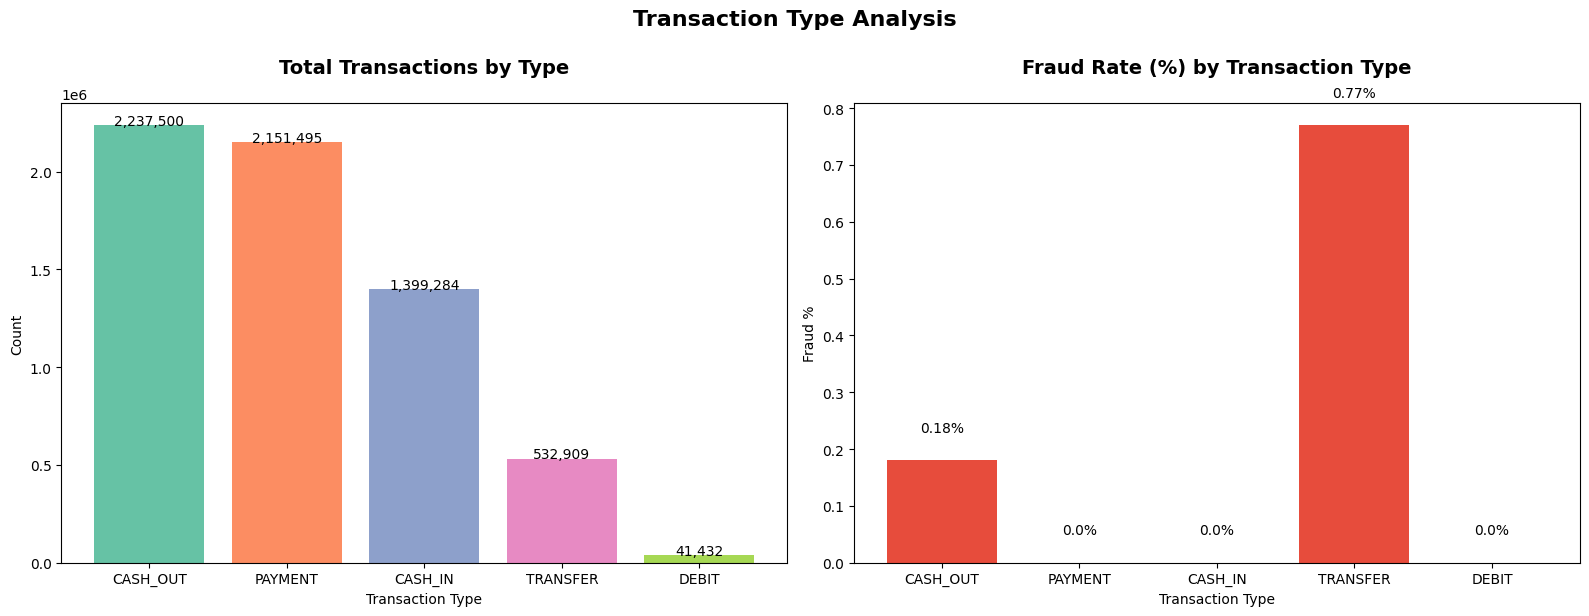

    type   count  fraud_count  fraud_pct
CASH_OUT 2237500         4116       0.18
 PAYMENT 2151495            0       0.00
 CASH_IN 1399284            0       0.00
TRANSFER  532909         4097       0.77
   DEBIT   41432            0       0.00


In [0]:
# ── Transaction type distribution ────────────────────────────────────────────
type_dist = (
    df.groupBy('type')
    .agg(
        F.count('*').alias('count'),
        F.sum('isFraud').alias('fraud_count')
    )
    .withColumn('fraud_pct', F.round(F.col('fraud_count') / F.col('count') * 100, 2))
    .orderBy(F.desc('count'))
).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total transactions by type
axes[0].bar(type_dist['type'], type_dist['count'], color=sns.color_palette('Set2', len(type_dist)))
axes[0].set_title('\nTotal Transactions by Type\n', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Transaction Type')
axes[0].set_ylabel('Count')
for i, v in enumerate(type_dist['count']):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

# Fraud percentage by type
colors = ['#e74c3c' if p > 0 else '#2ecc71' for p in type_dist['fraud_pct']]
axes[1].bar(type_dist['type'], type_dist['fraud_pct'], color=colors)
axes[1].set_title('\nFraud Rate (%) by Transaction Type\n', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Transaction Type')
axes[1].set_ylabel('Fraud %')
for i, v in enumerate(type_dist['fraud_pct']):
    axes[1].text(i, v + 0.05, f'{v}%', ha='center', fontsize=10)

plt.tight_layout()
plt.suptitle('Transaction Type Analysis', fontsize=16, fontweight='bold', y=1.02)
#plt.savefig('/content/plot_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(type_dist.to_string(index=False))

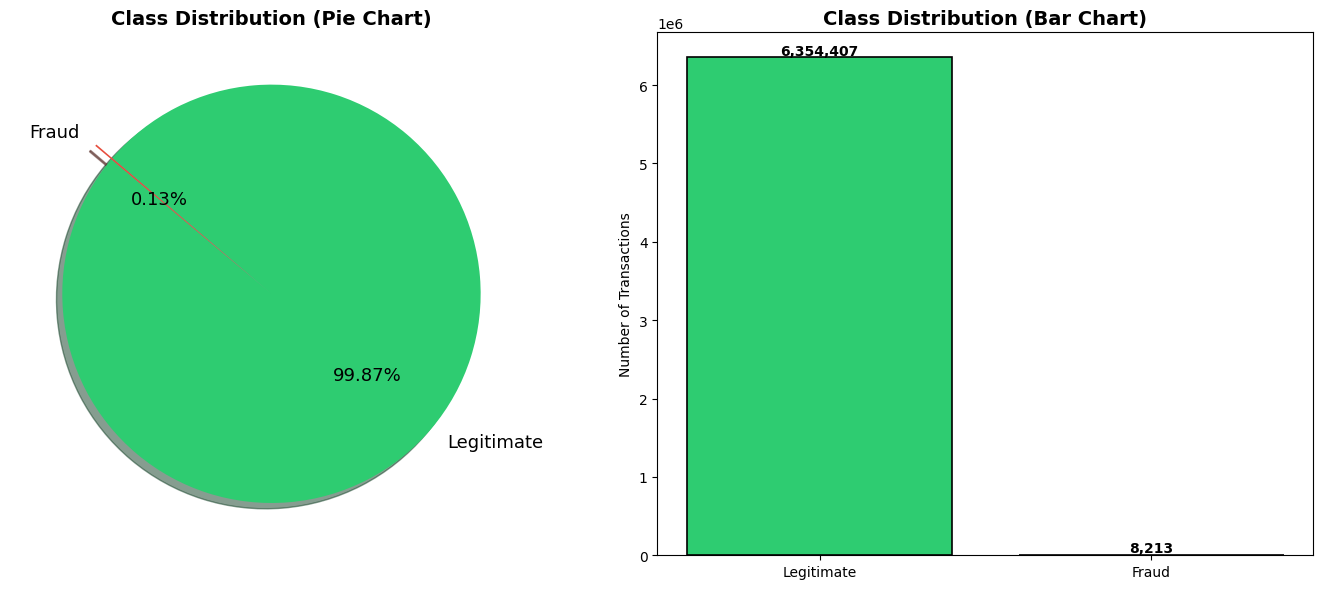


 Imbalance Ratio → Legitimate : Fraud = 773 : 1


In [0]:
# ── Class imbalance visualization ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

labels = ['Legitimate', 'Fraud']
sizes  = [legit_count, fraud_count]
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.1)

axes[0].pie(sizes, explode=explode, labels=labels, colors=colors,
            autopct='%1.2f%%', shadow=True, startangle=140,
            textprops={'fontsize': 13})
axes[0].set_title('Class Distribution (Pie Chart)', fontsize=14, fontweight='bold')

axes[1].bar(labels, sizes, color=colors, edgecolor='black', linewidth=1.2)
axes[1].set_title('Class Distribution (Bar Chart)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Transactions')
for i, v in enumerate(sizes):
    axes[1].text(i, v + legit_count * 0.005, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
#plt.savefig('/content/plot_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n Imbalance Ratio → Legitimate : Fraud = {legit_count//fraud_count} : 1")

#### Solution for Class Imbalance: Class Weighting
**Weight =  TotalCount / (2 x ClassCount)**

---
## Step 5: Feature Engineering

In [0]:
# ── Engineer new features ────────────────────────────────────────────────────
df_eng = (
    df
    # Balance error in origin account (account drained?)
    .withColumn('errorBalanceOrig',
                F.col('newbalanceOrig') + F.col('amount') - F.col('oldbalanceOrg'))

    # Balance error in destination account (money didn't arrive?)
    .withColumn('errorBalanceDest',
                F.col('oldbalanceDest') + F.col('amount') - F.col('newbalanceDest'))

    # Was origin account fully drained?
    .withColumn('origAccountDrained',
                F.when(F.col('newbalanceOrig') == 0, 1).otherwise(0))

    # Was destination a merchant? (starts with 'M')
    .withColumn('isMerchantDest',
                F.when(F.col('nameDest').startswith('M'), 1).otherwise(0))

    # Large transaction flag (above 90th percentile placeholder = 200k)
    .withColumn('isLargeTransaction',
                F.when(F.col('amount') > 200_000, 1).otherwise(0))

    # Ratio of amount to original balance
    .withColumn('amountToOrigBalanceRatio',
                F.when(F.col('oldbalanceOrg') > 0,
                       F.col('amount') / F.col('oldbalanceOrg')).otherwise(0.0))

    # Log-transform of amount (reduce skew)
    .withColumn('logAmount', F.log1p(F.col('amount')))
)

print("Feature engineering complete. New schema:")
df_eng.printSchema()

Feature engineering complete. New schema:
root
 |-- step: long (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrg: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: long (nullable = true)
 |-- isFlaggedFraud: long (nullable = true)
 |-- errorBalanceOrig: double (nullable = true)
 |-- errorBalanceDest: double (nullable = true)
 |-- origAccountDrained: integer (nullable = false)
 |-- isMerchantDest: integer (nullable = false)
 |-- isLargeTransaction: integer (nullable = false)
 |-- amountToOrigBalanceRatio: double (nullable = true)
 |-- logAmount: double (nullable = true)



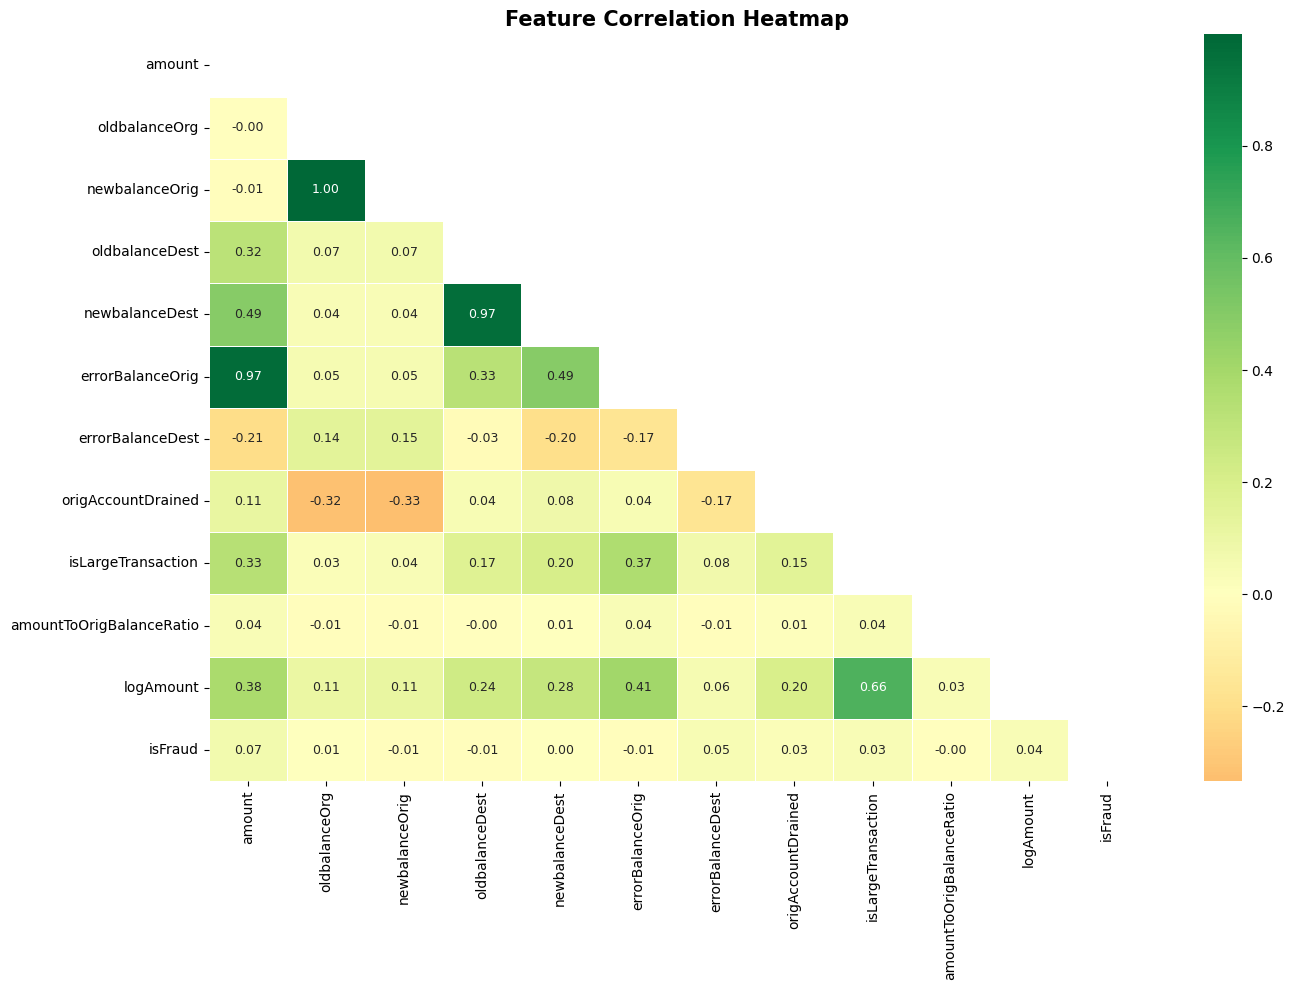

In [0]:
# ── Correlation heatmap (on sample) ─────────────────────────────────────────
num_cols = [
    'amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest',
    'errorBalanceOrig','errorBalanceDest','origAccountDrained',
    'isLargeTransaction','amountToOrigBalanceRatio','logAmount','isFraud'
]
corr_pd = df_eng.select(num_cols).sample(fraction=0.05, seed=42).toPandas()

corr_matrix = corr_pd.corr()
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

The heatmap shows how different features are related to each other.
- Values range from -1 to +1:
- +1 → strong positive relation
- -1 → strong negative relation
- 0 → no relation


---
##  Step 6: Data Preprocessing & ML Pipeline

In [0]:
# ── Encode categorical 'type' column ────────────────────────────────────────
indexer = StringIndexer(inputCol='type', outputCol='typeIndex', handleInvalid='keep')
encoder = OneHotEncoder(inputCol='typeIndex', outputCol='typeVec')

feature_cols = [
    'typeVec',
    'amount', 'logAmount',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'errorBalanceOrig', 'errorBalanceDest',
    'origAccountDrained', 'isMerchantDest',
    'isLargeTransaction', 'amountToOrigBalanceRatio'
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol='raw_features',
                             handleInvalid='skip')
scaler    = StandardScaler(inputCol='raw_features', outputCol='features',
                           withStd=True, withMean=False)

# Rename target column for MLlib convention
df_ml = df_eng.withColumn('label', F.col('isFraud').cast('double'))

# ── Train / Test split  (stratify by manually balancing after split) ─────────
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)

# ── Handle class imbalance via class weights ─────────────────────────────────
total  = train_df.count()
n_pos  = train_df.filter(F.col('label') == 1).count()
n_neg  = train_df.filter(F.col('label') == 0).count()

weight_pos = total / (2 * n_pos)
weight_neg = total / (2 * n_neg)

train_df = train_df.withColumn(
    'classWeight',
    F.when(F.col('label') == 1, weight_pos).otherwise(weight_neg)
)

print(f"Train size : {total:,}")
print(f"  Fraud    : {n_pos:,}  → weight = {weight_pos:.2f}")
print(f"  Legit    : {n_neg:,}  → weight = {weight_neg:.2f}")
print(f"Test size  : {test_df.count():,}")

Train size : 5,089,823
  Fraud    : 6,542  → weight = 389.01
  Legit    : 5,083,281  → weight = 0.50
Test size  : 1,272,797


#### Train size : 5,089,823
####  Fraud    : 6,542  → weight = 389.01
####  Legit    : 5,083,281  → weight = 0.50
#### Test size  : 1,272,797

---
##  Step 7: Model Training

In [0]:
# ═══════════════════════════════════════════════════════════════════
#  MODEL 1 — Logistic Regression
# ═══════════════════════════════════════════════════════════════════
lr = LogisticRegression(
    featuresCol='features', labelCol='label',
    weightCol='classWeight',
    maxIter=20, regParam=0.01, elasticNetParam=0.0
)

pipeline_lr = Pipeline(stages=[indexer, encoder, assembler, scaler, lr])

print("⏳ Training Logistic Regression...")
model_lr = pipeline_lr.fit(train_df)
print("✅ Logistic Regression trained!")

⏳ Training Logistic Regression...
✅ Logistic Regression trained!


In [0]:
# ═══════════════════════════════════════════════════════════════════
#  MODEL 2 — Random Forest
# ═══════════════════════════════════════════════════════════════════
rf = RandomForestClassifier(
    featuresCol='features', labelCol='label',
    weightCol='classWeight',
    numTrees=100, maxDepth=8, seed=42,
    featureSubsetStrategy='sqrt'
)

pipeline_rf = Pipeline(stages=[indexer, encoder, assembler, scaler, rf])

print("⏳ Training Random Forest (100 trees)...")
model_rf = pipeline_rf.fit(train_df)
print("✅ Random Forest trained!")

⏳ Training Random Forest (100 trees)...
✅ Random Forest trained!


In [0]:
# ═══════════════════════════════════════════════════════════════════
#  MODEL 3 — Gradient Boosted Trees
# ═══════════════════════════════════════════════════════════════════
gbt = GBTClassifier(
    featuresCol='features', labelCol='label',
    maxIter=50, maxDepth=6, stepSize=0.1, seed=42,
    subsamplingRate=0.8
)

pipeline_gbt = Pipeline(stages=[indexer, encoder, assembler, scaler, gbt])

print("⏳ Training Gradient Boosted Trees...")
model_gbt = pipeline_gbt.fit(train_df)
print("✅ GBT trained!")

⏳ Training Gradient Boosted Trees...
✅ GBT trained!


---
## Step 8: Model Evaluation
---

In [0]:
# ── Evaluation helpers ───────────────────────────────────────────────────────
from pyspark.mllib.evaluation import BinaryClassificationMetrics

def evaluate_model(model, test_data, model_name):
    predictions = model.transform(test_data)

    bin_eval  = BinaryClassificationEvaluator(labelCol='label',
                                               rawPredictionCol='rawPrediction')
    mc_eval_f1  = MulticlassClassificationEvaluator(labelCol='label',
                                                    predictionCol='prediction',
                                                    metricName='f1')
    mc_eval_pr  = MulticlassClassificationEvaluator(labelCol='label',
                                                    predictionCol='prediction',
                                                    metricName='weightedPrecision')
    mc_eval_re  = MulticlassClassificationEvaluator(labelCol='label',
                                                    predictionCol='prediction',
                                                    metricName='weightedRecall')
    mc_eval_acc = MulticlassClassificationEvaluator(labelCol='label',
                                                    predictionCol='prediction',
                                                    metricName='accuracy')

    roc_auc   = bin_eval.evaluate(predictions)
    f1        = mc_eval_f1.evaluate(predictions)
    precision = mc_eval_pr.evaluate(predictions)
    recall    = mc_eval_re.evaluate(predictions)
    accuracy  = mc_eval_acc.evaluate(predictions)

    # Confusion matrix
    cm = (
        predictions
        .groupBy('label', 'prediction')
        .count()
        .orderBy('label', 'prediction')
        .toPandas()
    )

    print(f"\n{'='*55}")
    print(f"  Model  : {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {accuracy:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc_auc:.4f}")

    return {
        'Model': model_name,
        'Accuracy':  round(accuracy,  4),
        'Precision': round(precision, 4),
        'Recall':    round(recall,    4),
        'F1':        round(f1,        4),
        'ROC-AUC':   round(roc_auc,   4),
        'cm':        cm,
        'predictions': predictions
    }

In [0]:
results_lr  = evaluate_model(model_lr,  test_df, 'Logistic Regression')
results_rf  = evaluate_model(model_rf,  test_df, 'Random Forest')
results_gbt = evaluate_model(model_gbt, test_df, 'Gradient Boosted Trees')


  Model  : Logistic Regression
  Accuracy  : 0.9152
  Precision : 0.9987
  Recall    : 0.9152
  F1-Score  : 0.9545
  ROC-AUC   : 0.9839

  Model  : Random Forest
  Accuracy  : 0.9999
  Precision : 0.9999
  Recall    : 0.9999
  F1-Score  : 0.9999
  ROC-AUC   : 0.9997

  Model  : Gradient Boosted Trees
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000
  ROC-AUC   : 0.9994


In [0]:
# ── Comparison table ─────────────────────────────────────────────────────────
metrics_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('cm', 'predictions')}
    for r in [results_lr, results_rf, results_gbt]
])

print("\n" + "="*70)
print("  MODEL COMPARISON SUMMARY")
print("="*70)
print(metrics_df.to_string(index=False))
print()
best = metrics_df.loc[metrics_df['ROC-AUC'].idxmax(), 'Model']
print(f"  🏆 Best Model by ROC-AUC: {best}")


  MODEL COMPARISON SUMMARY
                 Model  Accuracy  Precision  Recall     F1  ROC-AUC
   Logistic Regression    0.9152     0.9987  0.9152 0.9545   0.9839
         Random Forest    0.9999     0.9999  0.9999 0.9999   0.9997
Gradient Boosted Trees    1.0000     1.0000  1.0000 1.0000   0.9994

  🏆 Best Model by ROC-AUC: Random Forest


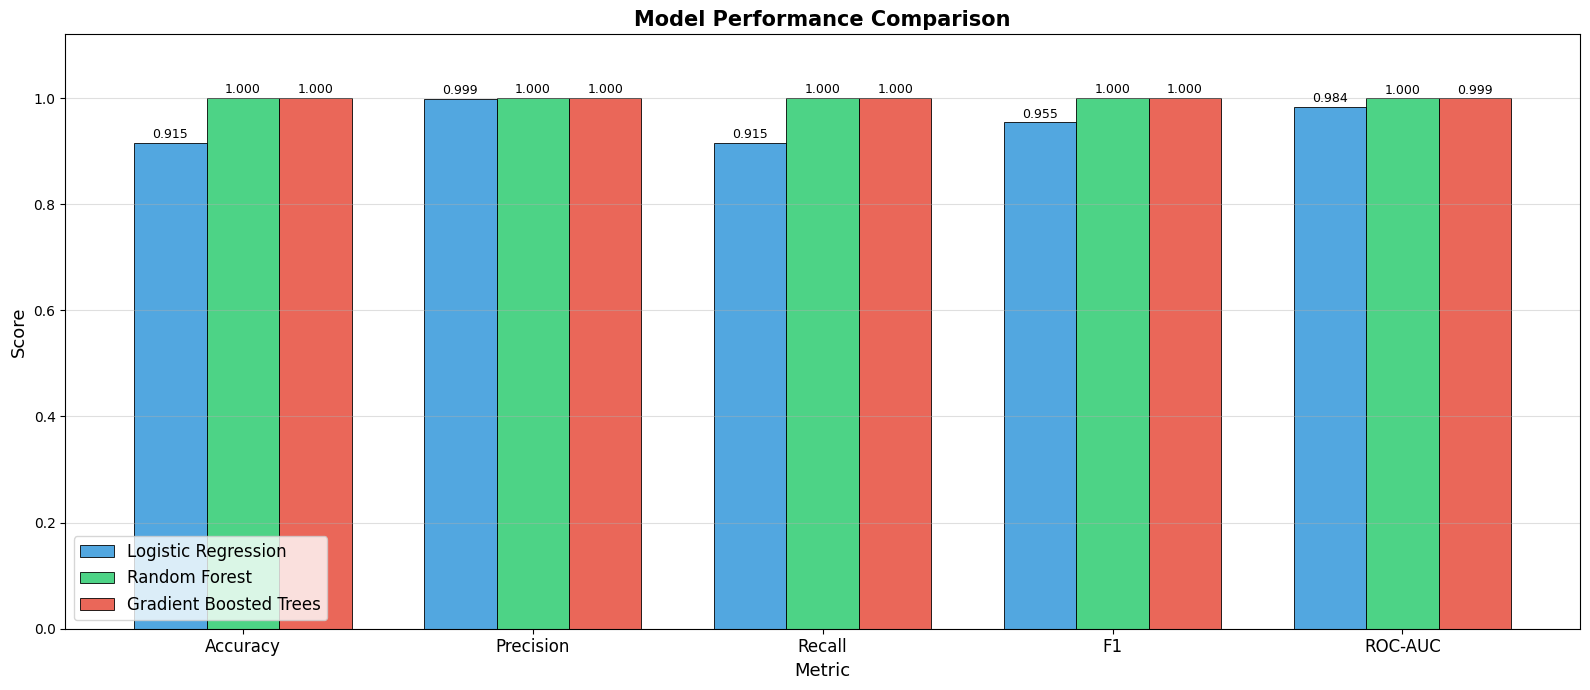

In [0]:
# ── Bar chart comparison ─────────────────────────────────────────────────────
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metric_names))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 7))
colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, (_, row) in enumerate(metrics_df.iterrows()):
    vals = [row[m] for m in metric_names]
    bars = ax.bar(x + i * width, vals, width, label=row['Model'],
                  color=colors[i], edgecolor='black', linewidth=0.7, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Metric', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
#plt.savefig('/content/plot_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

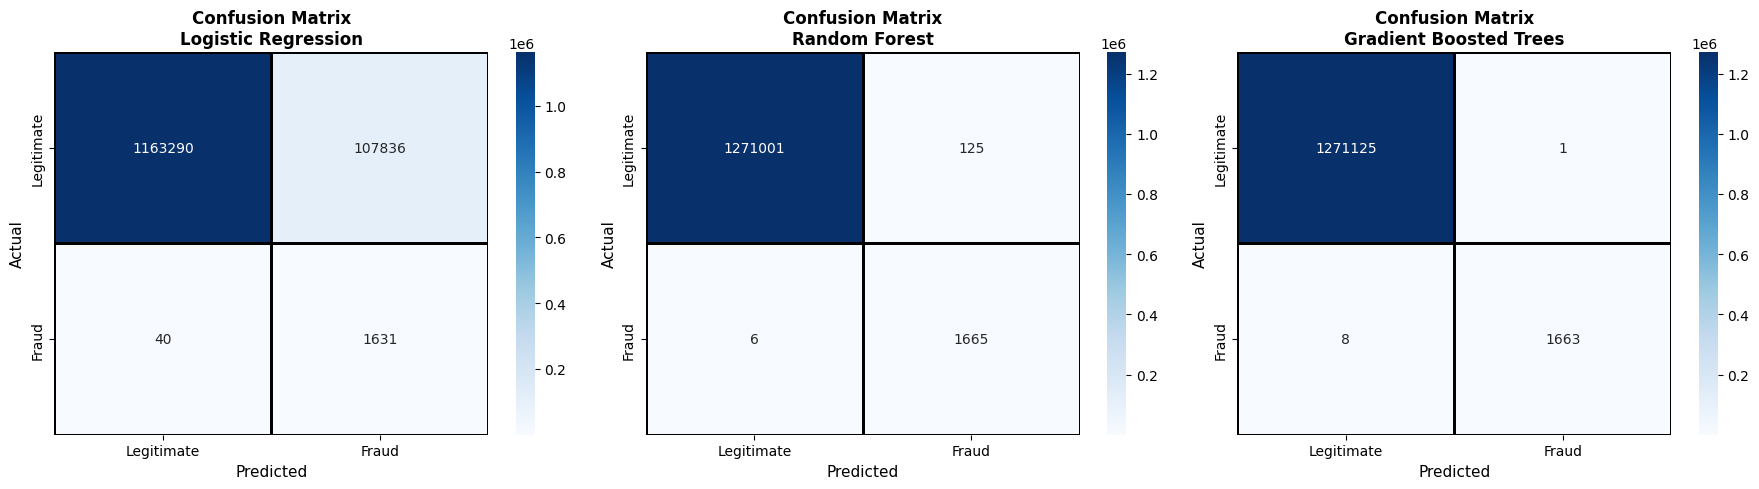

In [0]:
# ── Confusion matrices ───────────────────────────────────────────────────────
def plot_confusion_matrix(cm_df, model_name, ax):
    label_vals = sorted(cm_df['label'].unique())
    matrix = np.zeros((2, 2), dtype=int)
    for _, row in cm_df.iterrows():
        r, c = int(row['label']), int(row['prediction'])
        if r < 2 and c < 2:
            matrix[r][c] = int(row['count'])

    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'],
                linewidths=1, linecolor='black')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(f'Confusion Matrix\n{model_name}', fontsize=12, fontweight='bold')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, result in zip(axes, [results_lr, results_rf, results_gbt]):
    plot_confusion_matrix(result['cm'], result['Model'], ax)

plt.tight_layout()
plt.show()

---
## Step 9: Feature Importance (Random Forest)

/home/spark-25e7c3af-94d6-4b88-97ff-cb/.ipykernel/2039/command-7258899232532662-1092698727:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette=palette)


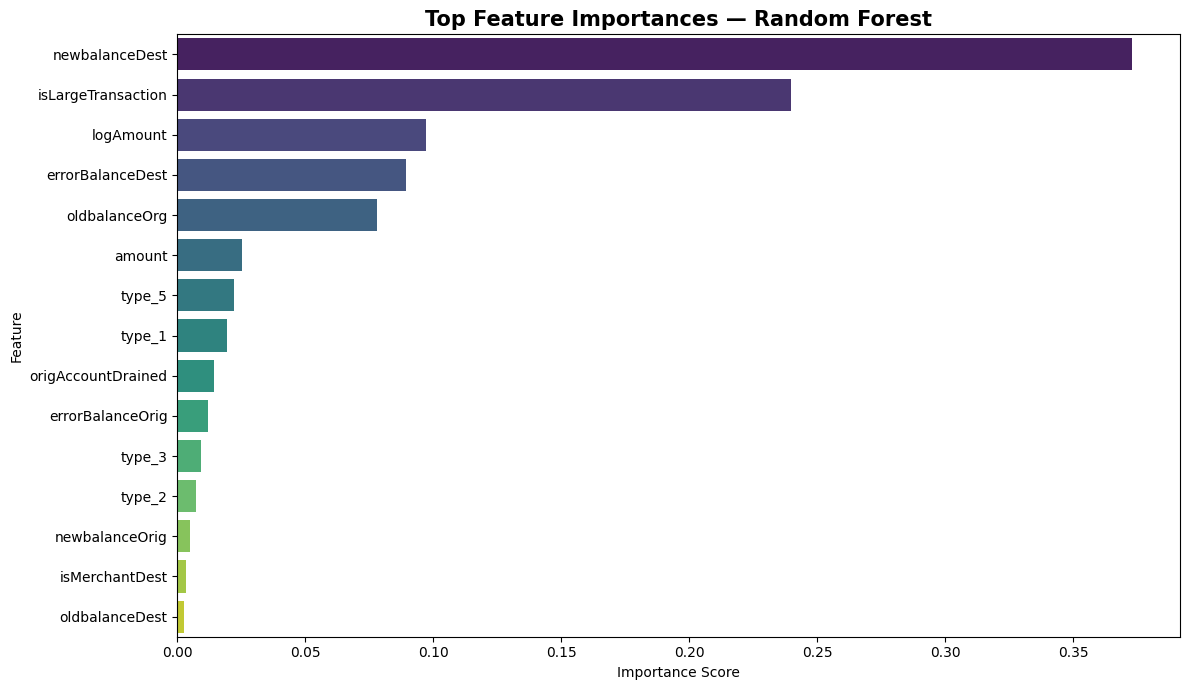

In [0]:
# Extract feature importances from the Random Forest model
rf_model_stage = model_rf.stages[-1]
importances    = rf_model_stage.featureImportances.toArray()

# Build feature name list (OHE expands 'type' into N-1 binary cols)
n_type_cats  = model_rf.stages[1].categorySizes[0]    # Get the actual category count
type_feat_names = [f'type_{i}' for i in range(n_type_cats)]
other_features  = [
    'amount', 'logAmount',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'errorBalanceOrig', 'errorBalanceDest',
    'origAccountDrained', 'isMerchantDest',
    'isLargeTransaction', 'amountToOrigBalanceRatio'
]
all_feature_names = type_feat_names + other_features
all_feature_names = all_feature_names[:len(importances)]  # safety trim

fi_df = pd.DataFrame({'Feature': all_feature_names,
                      'Importance': importances[:len(all_feature_names)]})
fi_df = fi_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(12, 7))
palette = sns.color_palette('viridis', len(fi_df))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette=palette)
plt.title('Top Feature Importances — Random Forest', fontsize=15, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()

plt.show()

---
##  Step 10: Real-Time Fraud Prediction Simulation

In [0]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql import functions as F

# Create Spark DataFrame directly (no pandas needed)
incoming_data = [
    (1, 'TRANSFER', 1350000.0, 'C9999001', 1350000.0, 0.0, 'C8888001', 0.0, 350000.0),
    (2, 'PAYMENT', 1200.0, 'C9999002', 20000.0, 18800.0, 'M1230001', 0.0, 0.0),
    (3, 'CASH_OUT', 180000.0, 'C9999003', 180000.0, 0.0, 'C7777001', 5000.0, 0.0),
    (4, 'DEBIT', 500.0, 'C9999004', 75000.0, 74500.0, 'M9990001', 0.0, 0.0),
    (5, 'TRANSFER', 920000.0, 'C9999005', 920000.0, 0.0, 'C6666001', 0.0, 0.0)
]

columns = ['step','type','amount','nameOrig','oldbalanceOrg','newbalanceOrig',
           'nameDest','oldbalanceDest','newbalanceDest']

spark_incoming = spark.createDataFrame(incoming_data, columns)

# Feature Engineering in Spark (must match training!)
spark_incoming = spark_incoming \
    .withColumn("errorBalanceOrig", 
        F.col("newbalanceOrig") + F.col("amount") - F.col("oldbalanceOrg")) \
    .withColumn("errorBalanceDest", 
        F.col("oldbalanceDest") + F.col("amount") - F.col("newbalanceDest")) \
    .withColumn("origAccountDrained", 
        F.when(F.col("newbalanceOrig") == 0, 1.0).otherwise(0.0)) \
    .withColumn("isMerchantDest", 
        F.when(F.col("nameDest").startswith("M"), 1.0).otherwise(0.0)) \
    .withColumn("isLargeTransaction", 
        F.when(F.col("amount") > 200000, 1.0).otherwise(0.0)) \
    .withColumn("amountToOrigBalanceRatio",
        F.when(F.col("oldbalanceOrg") > 0, 
               F.col("amount") / F.col("oldbalanceOrg")).otherwise(0.0)) \
    .withColumn("logAmount", F.log1p("amount"))

# Apply trained Spark ML model
preds = model_lr.transform(spark_incoming)

# Extract fraud probability (index 1 = fraud class)

result_display = preds.select(
    'step', 'type', 'amount', 'nameOrig', 'nameDest',
    F.col('prediction').cast('int').alias('predicted_fraud'),
    vector_to_array(F.col('probability'))[1].alias('fraud_probability')
)

print("=" * 95)
print("\n Real-Time Fraud Prediction Results:")
print("=" * 95)
display(result_display)
print("  prediction = 1 → 🚨 FRAUD ALERT")
print("  prediction = 0 → ✅ LEGITIMATE")


 Real-Time Fraud Prediction Results:


step,type,amount,nameOrig,nameDest,predicted_fraud,fraud_probability
1,TRANSFER,1350000.0,C9999001,C8888001,1,0.972316818681165
2,PAYMENT,1200.0,C9999002,M1230001,0,0.0027811535638587737
3,CASH_OUT,180000.0,C9999003,C7777001,1,0.6036477631183448
4,DEBIT,500.0,C9999004,M9990001,0,0.001430801660499137
5,TRANSFER,920000.0,C9999005,C6666001,1,0.9608162244079851


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

  prediction = 1 → 🚨 FRAUD ALERT
  prediction = 0 → ✅ LEGITIMATE
